In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
data = pd.read_csv("./winning_deck_results.csv", index_col=0)
# Turn the won column into boolean
data['won'] = data['won'].map({' True': True, " False": False})

In [8]:
visible_cards = data.iloc[:, [2, 9, 17, 20, 24, 27, 29]]
deck_cards = data.iloc[:, 30:]

In [45]:
data.describe()

,num_moves,x0,x1,x2,x3,x4,x5,x6,x7,x8,...,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,58.485200,26.343500,26.414100,26.556900,26.616500,26.566200,26.531400,26.360500,26.734400,26.16500,...,26.263300,26.90740,26.448000,26.441100,26.441700,26.532300,26.515900,26.510100,26.661200,26.322400
std,39.521622,14.988768,14.881235,14.991859,14.981458,15.025252,15.052364,15.027346,14.980758,15.09299,...,14.984026,15.05653,14.975043,14.942324,15.064843,15.065851,14.940063,15.024835,14.935211,15.052512
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,29.000000,13.000000,14.000000,14.000000,14.000000,13.000000,13.000000,13.000000,14.000000,13.00000,...,13.000000,14.00000,13.000000,13.000000,13.000000,13.000000,14.000000,14.000000,14.000000,13.000000
50%,47.000000,26.000000,26.000000,27.000000,27.000000,27.000000,27.000000,26.000000,27.000000,26.00000,...,26.000000,27.00000,27.000000,27.000000,26.000000,27.000000,26.000000,26.000000,27.000000,26.000000
75%,75.000000,39.000000,39.000000,40.000000,40.000000,40.000000,40.000000,39.000000,40.000000,39.00000,...,39.000000,40.00000,39.000000,39.000000,39.000000,40.000000,39.000000,40.000000,40.000000,39.000000
max,156.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.00000,...,52.000000,52.00000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000


<Axes: xlabel='won', ylabel='num_moves'>

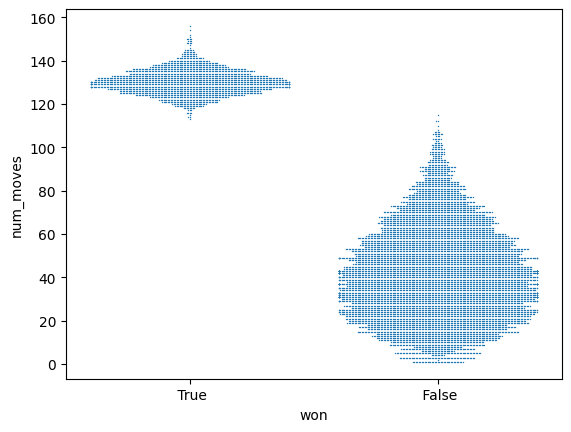

In [3]:
sns.swarmplot(x=data['won'], y=data['num_moves'], size=1)

In [34]:
max_loss = data.loc[data['won'] == False, 'num_moves'].max()
min_win = data.loc[data['won'] == True, 'num_moves'].min()
print(max_loss, min_win)

115 113


In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
kfold = StratifiedKFold(n_splits=1871)

In [5]:
X = data.iloc[:, 2:].values
y = data.iloc[:, 1].values
sc = StandardScaler()
sc.fit(X)
X_sc = sc.transform(X)

In [77]:
scores = []
for k, (train, test) in enumerate(kfold.split(X_sc, y)):  # iterator
    lr_model = LogisticRegression(random_state=1, solver='lbfgs')
    # print(train.shape, test.shape)
    lr_model.fit(X_sc[train], y[train])
    score = lr_model.score(X_sc[test], y[test])
    scores.append(score)
    print(
        f'Fold:{k+1:2d}, Class dist.:{np.bincount(y[train])}, Acc: {score:.3f}')

Fold: 1, Class dist.:[8124 1870], Acc: 0.833
Fold: 2, Class dist.:[8124 1870], Acc: 0.833
Fold: 3, Class dist.:[8124 1870], Acc: 0.833
Fold: 4, Class dist.:[8124 1870], Acc: 0.833
Fold: 5, Class dist.:[8124 1870], Acc: 0.833
Fold: 6, Class dist.:[8124 1870], Acc: 0.833
Fold: 7, Class dist.:[8124 1870], Acc: 0.833
Fold: 8, Class dist.:[8124 1870], Acc: 0.833
Fold: 9, Class dist.:[8124 1870], Acc: 0.833
Fold:10, Class dist.:[8124 1870], Acc: 0.833
Fold:11, Class dist.:[8124 1870], Acc: 0.833
Fold:12, Class dist.:[8124 1870], Acc: 0.833
Fold:13, Class dist.:[8124 1870], Acc: 0.833
Fold:14, Class dist.:[8124 1870], Acc: 0.833
Fold:15, Class dist.:[8124 1870], Acc: 0.833
Fold:16, Class dist.:[8124 1870], Acc: 0.833
Fold:17, Class dist.:[8124 1870], Acc: 0.833
Fold:18, Class dist.:[8124 1870], Acc: 0.833
Fold:19, Class dist.:[8124 1870], Acc: 0.833
Fold:20, Class dist.:[8124 1870], Acc: 0.833
Fold:21, Class dist.:[8124 1870], Acc: 0.833
Fold:22, Class dist.:[8124 1870], Acc: 0.833
Fold:23, C

In [78]:
print(f'CV accuracy : {np.mean(scores):.3f}, +/- {np.std(scores):.3f}')

CV accuracy : 0.811, +/- 0.016


In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

In [ ]:
names = ["KNN", "Linear SVM", "RBF SVM", "Gaussian Process",
         "Decision Tree", "Random Forest", "Neural Net", "AdaBoost",
         "Naive Bayes", "QDA", 'Logistic Reg']
scores = []  # store (name, mean, std_dev) for each classifier
classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    LogisticRegression(random_state=1, solver='lbfgs')
]

# iterate over classifiers
for name, clf in zip(names, classifiers):
    cvs = cross_val_score(estimator=clf, X=X_sc, y=y, cv=10, n_jobs=-1)
    scores.append((name, np.mean(cvs), np.std(cvs)))